# Label Percentage Plot

Plots the percentage of molecules carrying each label in `hmcn_dataset.csv`.
Produces two figures:
1. Fine-grained labels (138 `fine_*` columns)
2. Meta-categories (12 `meta_*` columns)

Adjust `DATA_PATH` in the CONFIG cell if your file lives elsewhere.

In [1]:
# CONFIG
DATA_PATH = "hmcn_dataset.csv"   # canonical dataset, comma-delimited
FINE_PREFIX = "fine_"
META_PREFIX = "meta_"
FIGSIZE_FINE = (10, 22)
FIGSIZE_META = (8, 6)
SAVE_FIGS = True
OUT_DIR = "."


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]} molecules, {df.shape[1]} columns")


Loaded 4976 molecules, 1156 columns


In [3]:
def label_percentages(df, prefix):
    label_cols = [c for c in df.columns if c.startswith(prefix)]
    pct = (df[label_cols].sum() / len(df) * 100).sort_values(ascending=False)
    pct.index = [c[len(prefix):] for c in pct.index]
    return pct

fine_pct = label_percentages(df, FINE_PREFIX)
meta_pct = label_percentages(df, META_PREFIX)

print(f"{len(fine_pct)} fine labels, {len(meta_pct)} meta labels")


138 fine labels, 12 meta labels


In [4]:
def plot_label_pct(pct_series, title, figsize, out_name=None):
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(pct_series.index[::-1], pct_series.values[::-1], color="#3b5f8a")
    ax.set_xlabel("% of molecules with label")
    ax.set_title(title)
    for i, v in enumerate(pct_series.values[::-1]):
        ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=8)
    fig.tight_layout()
    if SAVE_FIGS and out_name:
        fig.savefig(f"{OUT_DIR}/{out_name}", dpi=150, bbox_inches="tight")
    plt.show()
    return fig


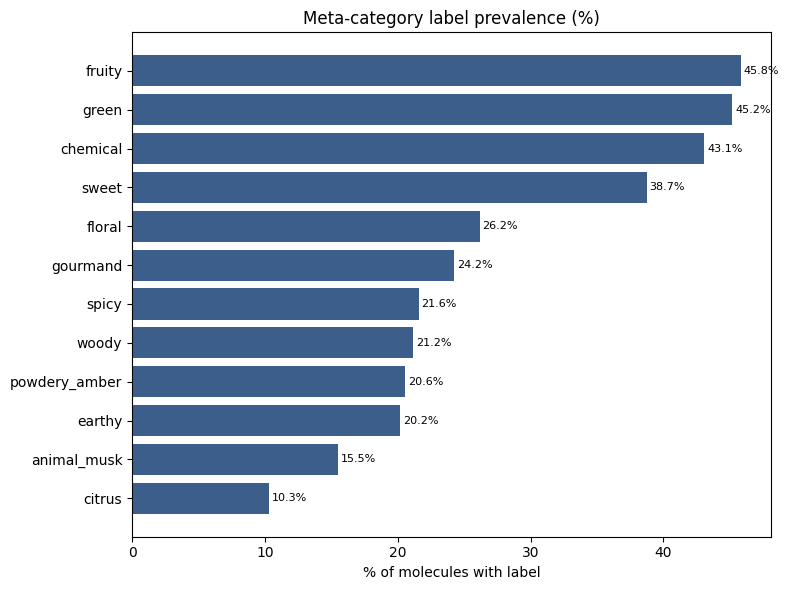

In [5]:
fig_meta = plot_label_pct(meta_pct, "Meta-category label prevalence (%)", FIGSIZE_META, "meta_label_percentage.png")


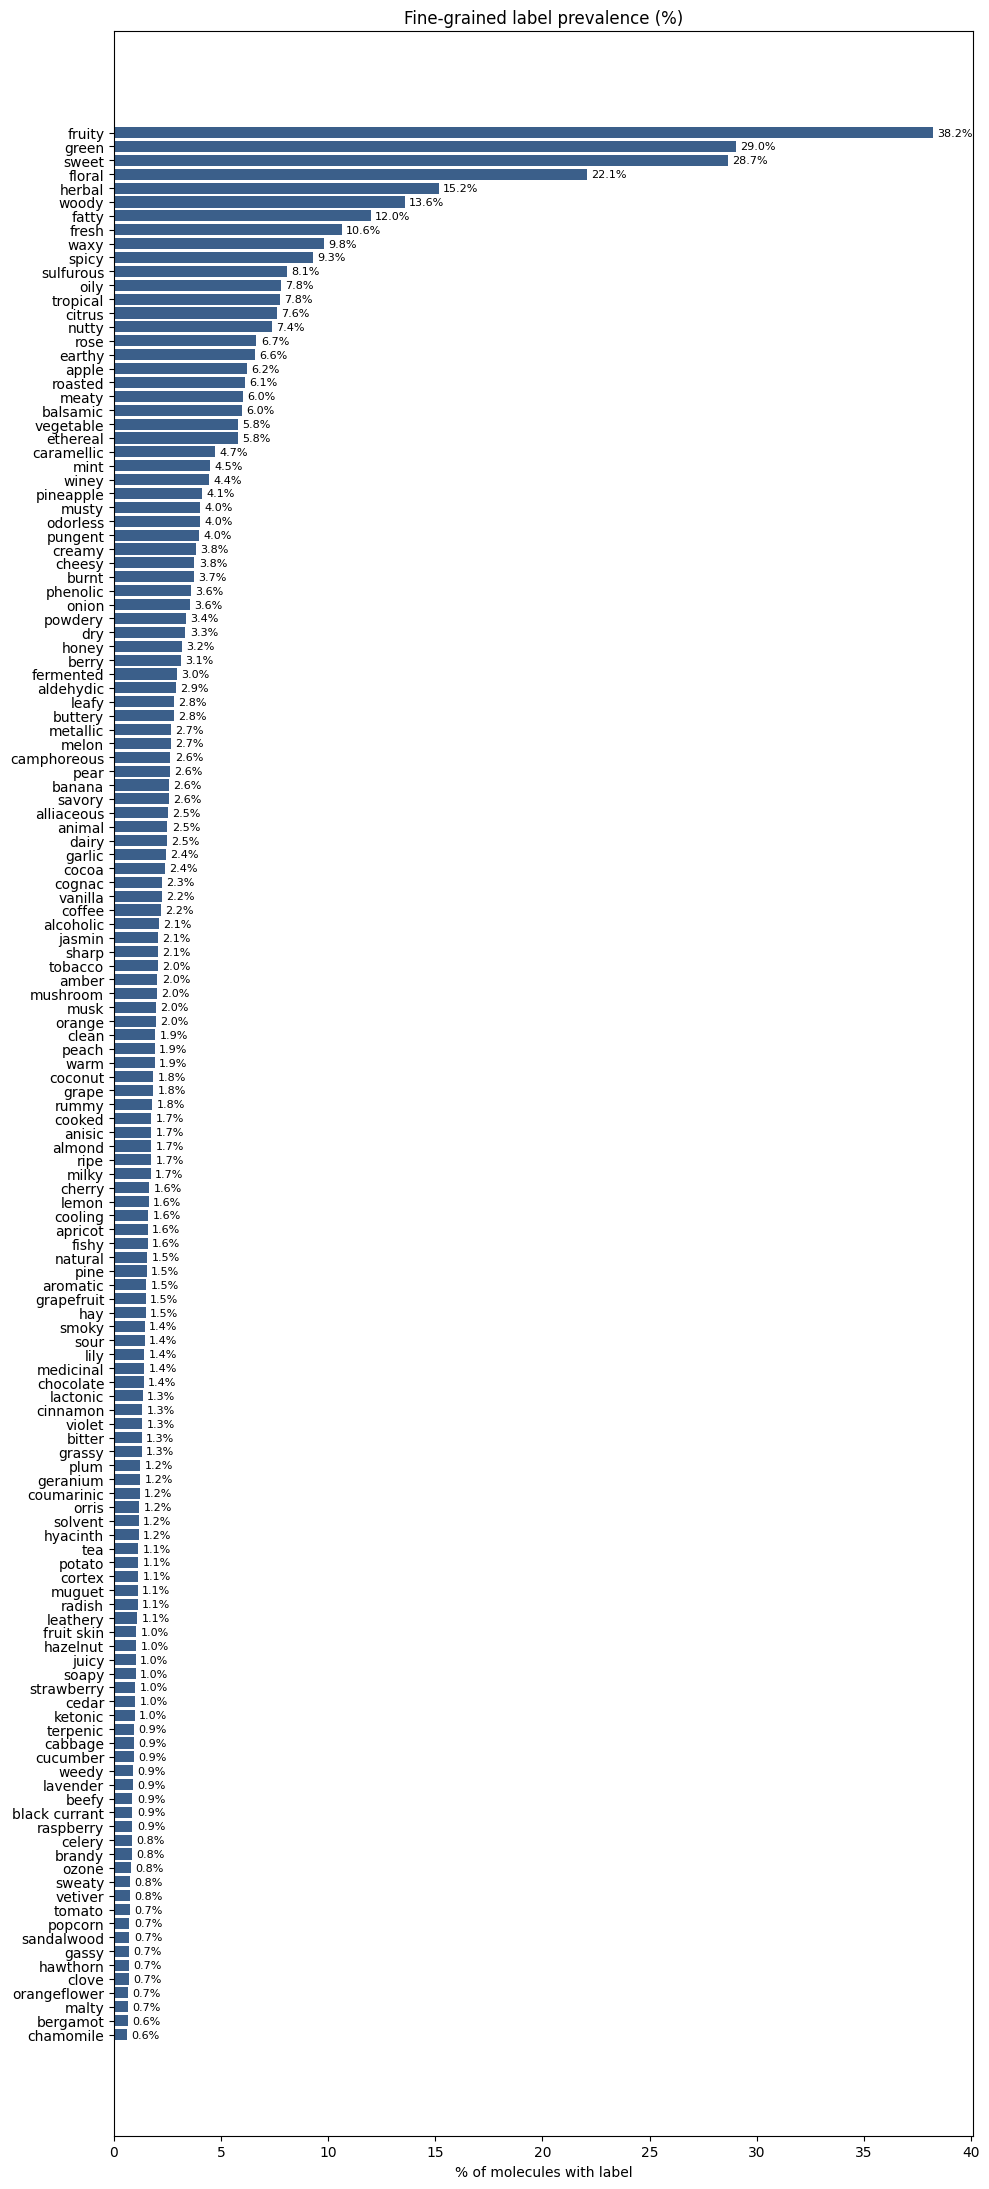

In [6]:
fig_fine = plot_label_pct(fine_pct, "Fine-grained label prevalence (%)", FIGSIZE_FINE, "fine_label_percentage.png")


## Summary table (optional)

In [7]:
summary = pd.concat(
    [fine_pct.rename("pct_fine"), meta_pct.rename("pct_meta")],
    axis=1
)
summary.to_csv(f"{OUT_DIR}/label_percentages_summary.csv")
fine_pct.head(20)


fruity       38.203376
green        29.039389
sweet        28.657556
floral       22.086013
herbal       15.152733
woody        13.565113
fatty        11.997588
fresh        10.631029
waxy          9.786977
spicy         9.304662
sulfurous     8.078778
oily          7.797428
tropical      7.757235
citrus        7.596463
nutty         7.355305
rose          6.651929
earthy        6.571543
apple         6.189711
roasted       6.129421
meaty         6.008842
dtype: float64